#### Imports and setup

In [23]:
import os
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.optim as optim
from torch.utils.data import DataLoader

import porepy as pp


from src.tpf_lab.models.run_models import run_time_dependent_model
from src.tpf_lab.models.two_phase_flow import TwoPhaseFlow
from src.tpf_lab.ml.ml_ad import nn_wrapper, set_nn_to_eval
from src.tpf_lab.ml.nn import BaseNN
from src.tpf_lab.ml.datasets import DatasetWithNoise, RelPermW_BrooksCorey, RelPermN_BrooksCorey
from src.tpf_lab.ml.train import train



# Direct input
plt.rcParams["text.latex.preamble"] = r"\usepackage{lmodern}"
# Options
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.size": 11,
        "font.family": "lmodern",
    }
)

os.makedirs("saved_nns", exist_ok=True)

#### Train a relative permeability model

In [25]:
rel_perm_w_train_data = DatasetWithNoise(len=5000, model="Brooks-Corey-W", mean=0.1, std=0.2)
rel_perm_w_train_dataloader = DataLoader(rel_perm_w_train_data, batch_size=64)

model = BaseNN({"depth": 5, "final_act": "linear"})
trainer = optim.Adam(model.parameters())
train(rel_perm_w_train_dataloader, model, trainer, epochs=150)
torch.save(
    model.state_dict(),
    os.path.join(
        "saved_nns", "BaseNN_RelPermW_BrooksCorey_1HiddenLayers_mean0.1_std0.2.pt"
    ),
)

epoch 149: 100%|██████████| 150/150 [02:07<00:00,  1.18it/s]


In [26]:
rel_perm_n_train_data = DatasetWithNoise(len=5000, model="Brooks-Corey-N", mean=0.1, std=0.2)
rel_perm_n_train_dataloader = DataLoader(rel_perm_n_train_data, batch_size=64)

model = BaseNN({"depth": 5, "final_act": "linear"})
trainer = optim.Adam(model.parameters())
train(rel_perm_n_train_dataloader, model, trainer, epochs=150)
torch.save(
    model.state_dict(),
    os.path.join(
        "saved_nns", "BaseNN_RelPermN_BrooksCorey_1HiddenLayers_mean0.1_std0.2.pt"
    ),
)

epoch 149: 100%|██████████| 150/150 [02:20<00:00,  1.07it/s]


#### Map the curves

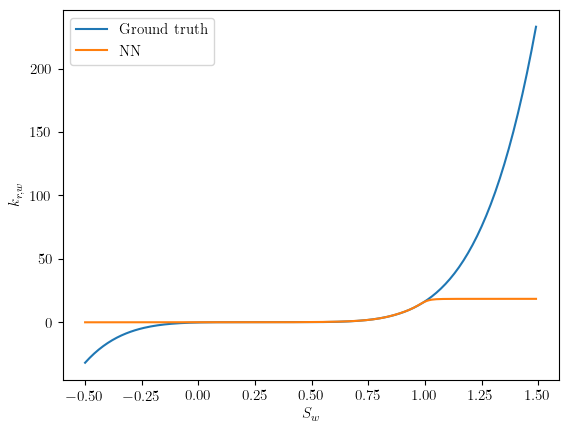

In [27]:
x = torch.arange(-0.5, 1.5, 0.01).unsqueeze(-1)
rel_perm_w_brooks_corey = RelPermW_BrooksCorey()
rel_perm_w_nn = BaseNN({"depth": 5, "final_act": "linear"})
rel_perm_w_nn.load_state_dict(torch.load(os.path.join(
    "saved_nns", "BaseNN_RelPermW_BrooksCorey_1HiddenLayers_mean0.1_std0.2.pt"
)))
y = rel_perm_w_brooks_corey(x)
y_hat = rel_perm_w_nn(x)
plt.figure()
plt.plot(x.numpy(force=True), y.numpy(force=True), label="Ground truth")
plt.plot(x.numpy(force=True), y_hat.numpy(force=True), label="NN")
# x, y = next(iter(w_train_dataloader))
# plt.scatter(
#     x.numpy(force=True),
#     y.numpy(force=True),
#     label="Data",
# )
plt.legend()
plt.xlabel(r"$S_w$")
plt.ylabel(r"$k_{r,w}$")
plt.savefig(
    os.path.join(
        "saved_nns", "BaseNN_RelPermN_BrooksCorey_1HiddenLayers_mean0.1_std0.2.png"
    )
)

#### Wrap the models in PorePy

In [28]:
class TwoPhaseFlow_NNRelPerms(TwoPhaseFlow):

    def __init__(self, params: dict | None = None) -> None:
        super().__init__(params)
        rel_perm_w_nn = BaseNN({"depth": 5, "final_act": "linear"})
        rel_perm_w_nn.load_state_dict(torch.load(os.path.join(
                "saved_nns", "BaseNN_RelPermW_BrooksCorey_1HiddenLayers_mean0.1_std0.2.pt"
            )))
        set_nn_to_eval(rel_perm_w_nn)
        rel_perm_w_nn_wrapped = nn_wrapper(rel_perm_w_nn)
        self.rel_perm_w_nn_function = pp.ad.Function(rel_perm_w_nn_wrapped, "rel_perm_w_nn")

        rel_perm_n_nn = BaseNN({"depth": 5, "final_act": "linear"})
        rel_perm_n_nn.load_state_dict(torch.load(os.path.join(
                "saved_nns", "BaseNN_RelPermN_BrooksCorey_1HiddenLayers_mean0.1_std0.2.pt"
            )))
        set_nn_to_eval(rel_perm_n_nn)
        rel_perm_n_nn_wrapped = nn_wrapper(rel_perm_n_nn)
        self.rel_perm_n_nn_function = pp.ad.Function(rel_perm_n_nn_wrapped, "rel_perm_n_nn")

    def _rel_perm_w(self) -> pp.ad.Operator:
        s = self._ad.saturation
        return self.rel_perm_w_nn_function(s)

    def _rel_perm_n(self) -> pp.ad.Operator:
        s = self._ad.saturation
        return self.rel_perm_n_nn_function(s)

    def _source_w(self, g: pp.Grid) -> np.ndarray:
        array: np.ndarray = super()._source_w(g)
        array[201] = 0.5
        return array

#### Setup and run a two phase flow model

In [30]:
cap_pressure_model = "linear"

params = {
    "formulation": "n_pressure_w_saturation",
    "file_name": f"nn_rel_perm_test",
    "folder_name": os.path.join(
        "results",
        "setup_tests",
        f"{date.today().strftime('%Y-%m-%d')}_pcap_{cap_pressure_model}",
    ),
}

model = TwoPhaseFlow_NNRelPerms(params)

model._cap_pressure_model = cap_pressure_model
model._time_step = 0.1
model._schedule = np.array([0, 10.0])
model.prepare_simulation()

run_time_dependent_model(model, {"max_iterations": 30})


time loop:   0%|          | 0/101 [00:00<?, ?it/s]

Newton loop:   0%|          | 0/30 [00:00<?, ?it/s]

/home/peter/miniconda3/envs/tpf_23-02/lib/python3.10/site-packages/porepy/models/abstract_model.py:300: UserWarning: PyPardiso could not be imported,
                    falling back on scipy.sparse.linalg.spsolve
  warnings.warn(


ValueError: Newton iterations did not converge